# Weekly Project - Week 4: Stereo Camera Calibration

We calibrate a stereo camera pair, then undistort and rectify the images. Rectification lines up the left and right images row by row, which our block matching function needs to work correctly.

OpenCV is not allowed for the block matching step, we use our own function for that.

- Step 1: find checkerboard corners in matching left and right pairs
- Step 2: calibrate each camera
- Step 3: stereo calibrate, to get the relation between the two cameras
- Step 4: stereo rectify, to compute the alignment
- Step 5: undistort and rectify the images
- Step 6: check the rectification
- Step 7: run our own block matcher

We start with the `rs` dataset, then repeat on `mynteye`.

In [1]:
import glob
import time

import cv2
import numpy as np
from matplotlib import pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view


## Finding the checkerboard size

We need to know how many internal corners the checkerboard has. Instead of guessing, we try a range of sizes on one image and see which one `findChessboardCorners` accepts.

In [2]:
sample = cv2.cvtColor(cv2.imread('rs/left-0000.png'), cv2.COLOR_BGR2GRAY)

found_sizes = []
for rows in range(4, 10):
    for cols in range(4, 10):
        ret, _ = cv2.findChessboardCorners(sample, (rows, cols), None)
        if ret:
            found_sizes.append((rows, cols))

print('Working pattern sizes:', found_sizes)


Working pattern sizes: [(6, 9), (9, 6)]


`(6, 9)` and `(9, 6)` are the same pattern, just with rows and columns swapped. We use `(6, 9)`. This size works for both the `rs` and `mynteye` datasets, they use the same physical checkerboard.

## Setup

`PATTERN_SIZE` is the number of internal corners. `SQUARE_SIZE` is the size of one square, in millimeters. This lets the calibration results, like the baseline between the two cameras, come out in real millimeters.

In [3]:
PATTERN_SIZE = (6, 9)
SQUARE_SIZE = 33.6  # mm

# Object points for one view of the checkerboard.
objp = np.zeros((PATTERN_SIZE[0] * PATTERN_SIZE[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:PATTERN_SIZE[0], 0:PATTERN_SIZE[1]].T.reshape(-1, 2)
objp *= SQUARE_SIZE

## Step 1: find corners in matching pairs

We need corners in both the left and right image of a pair, since stereo calibration needs to know where the same physical corner landed in each camera. If corners are found in only one of the two images, we skip that pair.

In [4]:
def find_stereo_corners(folder, pattern_size, objp):
    """Find checkerboard corners in matching left/right image pairs.

    Returns object points, left image points, right image points,
    and the image size. A pair is kept only if corners were found
    in both images.
    """
    left_paths = sorted(glob.glob(f'{folder}/left-*.png'))
    right_paths = sorted(glob.glob(f'{folder}/right-*.png'))

    objpoints, imgpoints_l, imgpoints_r = [], [], []
    image_size = None

    for lf, rf in zip(left_paths, right_paths):
        gray_l = cv2.cvtColor(cv2.imread(lf), cv2.COLOR_BGR2GRAY)
        gray_r = cv2.cvtColor(cv2.imread(rf), cv2.COLOR_BGR2GRAY)
        if image_size is None:
            image_size = gray_l.shape[::-1]  # (width, height)

        ret_l, corners_l = cv2.findChessboardCorners(gray_l, pattern_size, None)
        ret_r, corners_r = cv2.findChessboardCorners(gray_r, pattern_size, None)

        if ret_l and ret_r:
            objpoints.append(objp)
            imgpoints_l.append(corners_l)
            imgpoints_r.append(corners_r)

    return objpoints, imgpoints_l, imgpoints_r, image_size


Valid pairs: 76, image size: (640, 480)


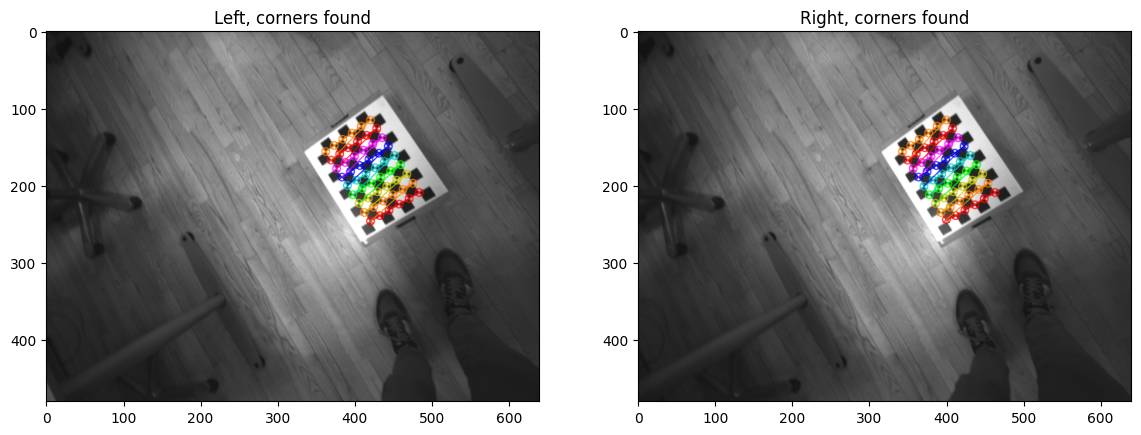

In [5]:
objpoints, imgpoints_l, imgpoints_r, image_size = find_stereo_corners('rs', PATTERN_SIZE, objp)
print(f'Valid pairs: {len(objpoints)}, image size: {image_size}')

# Sanity check, draw the detected corners on one pair.
sample_l = cv2.imread('rs/left-0000.png')
sample_r = cv2.imread('rs/right-0000.png')
cv2.drawChessboardCorners(sample_l, PATTERN_SIZE, imgpoints_l[0], True)
cv2.drawChessboardCorners(sample_r, PATTERN_SIZE, imgpoints_r[0], True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(sample_l, cv2.COLOR_BGR2RGB)); axes[0].set_title('Left, corners found')
axes[1].imshow(cv2.cvtColor(sample_r, cv2.COLOR_BGR2RGB)); axes[1].set_title('Right, corners found')
plt.show()


## Step 2: calibrate each camera

We calibrate the left and right camera separately. This gives us each camera's intrinsic matrix and distortion coefficients.

In [6]:
ret_l, mtx_l, dist_l, _, _ = cv2.calibrateCamera(objpoints, imgpoints_l, image_size, None, None)
ret_r, mtx_r, dist_r, _, _ = cv2.calibrateCamera(objpoints, imgpoints_r, image_size, None, None)

print(f'Left camera reprojection error:  {ret_l:.3f}')
print(f'Right camera reprojection error: {ret_r:.3f}')


Left camera reprojection error:  0.210
Right camera reprojection error: 0.199


The reprojection error is in pixels. It tells us how far off, on average, the calibrated model's predicted corner positions are from where the corners were actually detected. A value under 1 pixel is a good calibration.

## Step 3: stereo calibrate

`cv2.stereoCalibrate` finds the rotation `R` and translation `T` between the two cameras. `CALIB_FIX_INTRINSIC` tells it to trust the camera matrices and distortion coefficients we already computed in Step 2, and only solve for the relationship between the two cameras.

`T` is the position of the right camera relative to the left camera, in the same millimeter units as `SQUARE_SIZE`. Its length should roughly match the physical distance between the two lenses.

In [7]:
stereo_ret, mtx_l, dist_l, mtx_r, dist_r, R, T, E, F = cv2.stereoCalibrate(
    objpoints, imgpoints_l, imgpoints_r,
    mtx_l, dist_l, mtx_r, dist_r, image_size,
    flags=cv2.CALIB_FIX_INTRINSIC,
)

print(f'Stereo reprojection error: {stereo_ret:.3f}')
print(f'Translation between cameras (mm): {T.ravel()}')
print(f'Baseline (distance between cameras): {np.linalg.norm(T):.1f} mm')


Stereo reprojection error: 0.213
Translation between cameras (mm): [-4.98201447e+01  9.06479122e-03 -6.18839154e-02]
Baseline (distance between cameras): 49.8 mm


## Step 4: stereo rectify

`cv2.stereoRectify` computes new camera orientations, `R1` and `R2`, that make the left and right image planes parallel and row aligned. `P1` and `P2` are the projection matrices for these new views. `Q` can turn a disparity map into real 3D coordinates.

In [8]:
R1, R2, P1, P2, Q, roi1, roi2 = cv2.stereoRectify(
    mtx_l, dist_l, mtx_r, dist_r, image_size, R, T, alpha=0
)


## Step 5: undistort and rectify the images

`cv2.initUndistortRectifyMap` builds a pixel remapping table that does both jobs in one pass, it removes the lens distortion (using the camera matrix and distortion coefficients) and applies the rectifying rotation (`R1`/`R2`), landing on the new projection (`P1`/`P2`). This is why undistortion happens before rectification, the map is built from the undistorted geometry first, then rotated into alignment.

`cv2.remap` then applies that table to warp an actual image.

In [9]:
def build_rectify_maps(mtx_l, dist_l, mtx_r, dist_r, R1, R2, P1, P2, image_size):
    map_l = cv2.initUndistortRectifyMap(mtx_l, dist_l, R1, P1, image_size, cv2.CV_32FC1)
    map_r = cv2.initUndistortRectifyMap(mtx_r, dist_r, R2, P2, image_size, cv2.CV_32FC1)
    return map_l, map_r


def rectify_pair(img_l, img_r, map_l, map_r):
    rect_l = cv2.remap(img_l, map_l[0], map_l[1], cv2.INTER_LINEAR)
    rect_r = cv2.remap(img_r, map_r[0], map_r[1], cv2.INTER_LINEAR)
    return rect_l, rect_r


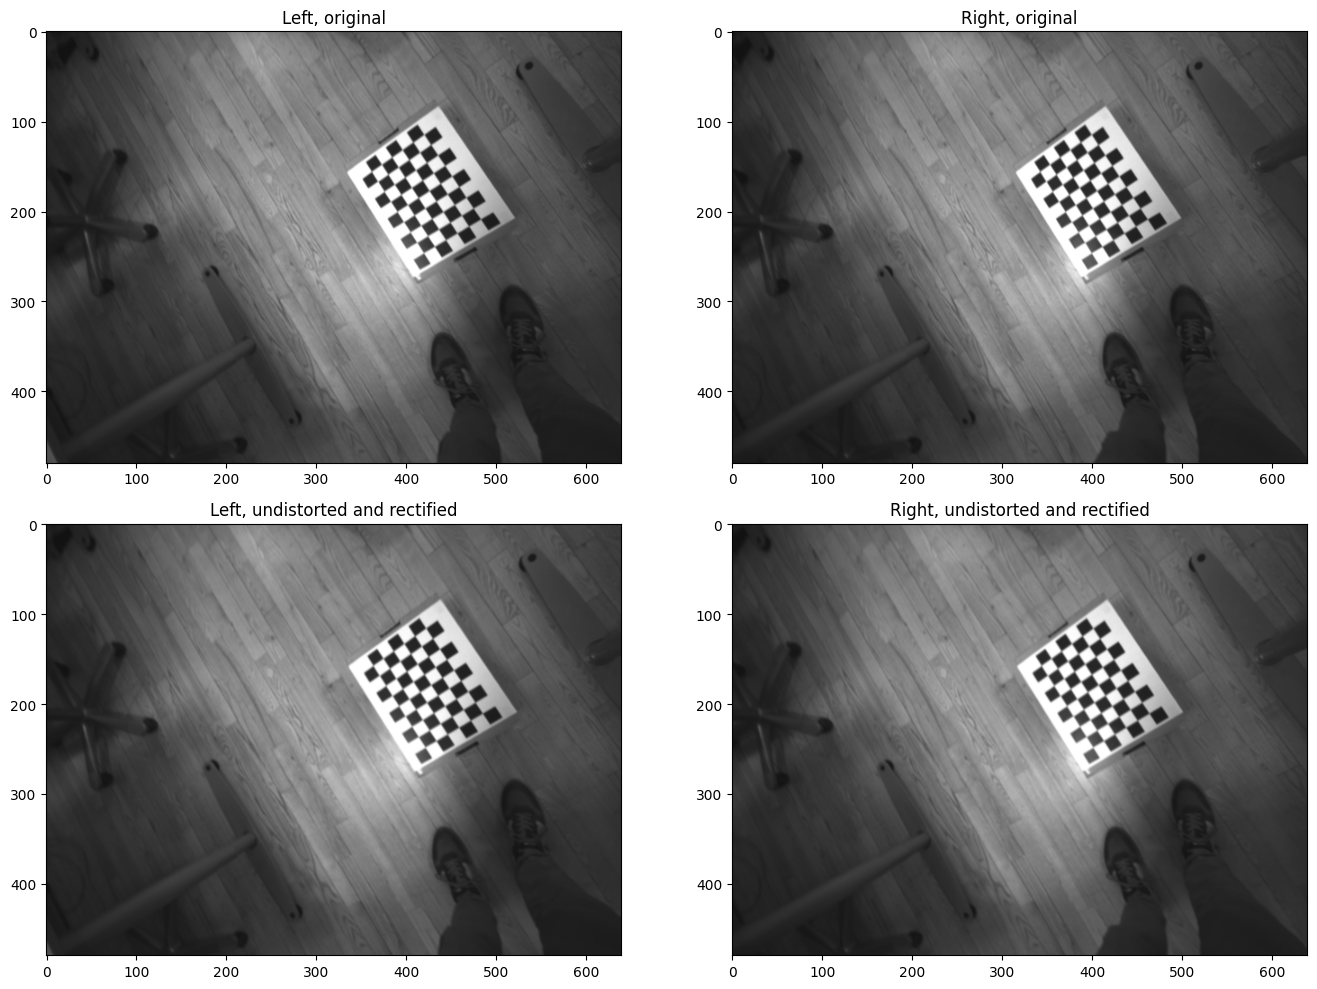

In [10]:
map_l, map_r = build_rectify_maps(mtx_l, dist_l, mtx_r, dist_r, R1, R2, P1, P2, image_size)

img_l = cv2.imread('rs/left-0000.png')
img_r = cv2.imread('rs/right-0000.png')
rect_l, rect_r = rectify_pair(img_l, img_r, map_l, map_r)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].imshow(cv2.cvtColor(img_l, cv2.COLOR_BGR2RGB));  axes[0, 0].set_title('Left, original')
axes[0, 1].imshow(cv2.cvtColor(img_r, cv2.COLOR_BGR2RGB));  axes[0, 1].set_title('Right, original')
axes[1, 0].imshow(cv2.cvtColor(rect_l, cv2.COLOR_BGR2RGB)); axes[1, 0].set_title('Left, undistorted and rectified')
axes[1, 1].imshow(cv2.cvtColor(rect_r, cv2.COLOR_BGR2RGB)); axes[1, 1].set_title('Right, undistorted and rectified')
plt.tight_layout()
plt.show()


## Step 6: check the rectification

If rectification worked, the same physical point should now sit on the same row (the same y coordinate) in both images. We check this visually, we stack the two rectified images side by side and draw horizontal lines across both. Matching features, like the checkerboard corners or the edge of a shoe, should line up with the same line in both halves.

In [11]:
def draw_rectification_check(rect_l, rect_r, step=40):
    stacked = np.hstack([rect_l, rect_r])
    stacked = stacked.copy()
    for y in range(0, stacked.shape[0], step):
        cv2.line(stacked, (0, y), (stacked.shape[1], y), (0, 255, 0), 1)
    return stacked


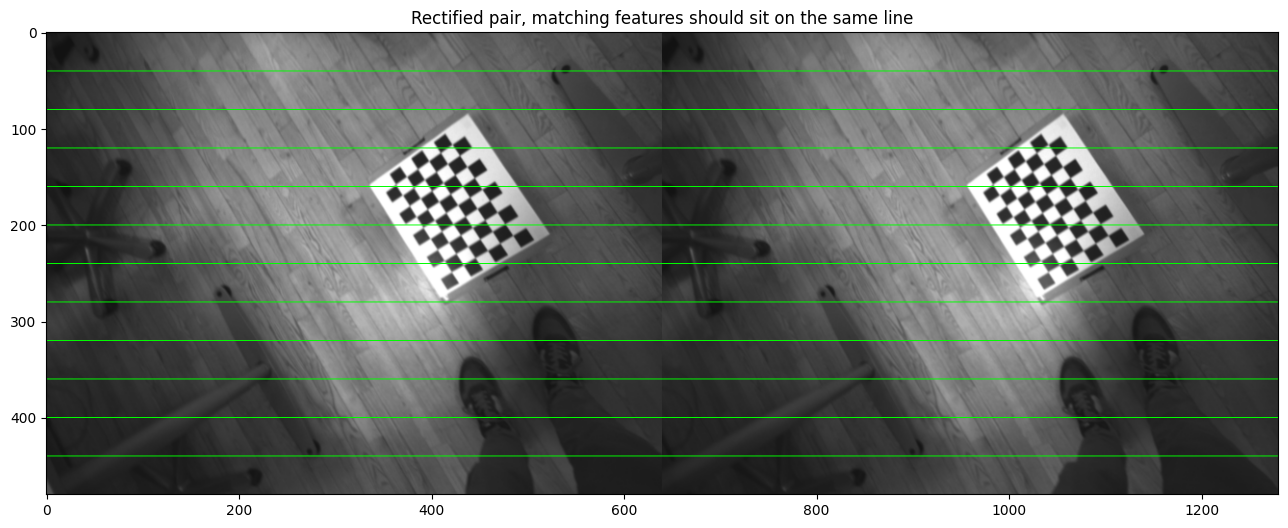

In [12]:
check_img = draw_rectification_check(rect_l, rect_r)
plt.figure(figsize=(16, 6))
plt.imshow(cv2.cvtColor(check_img, cv2.COLOR_BGR2RGB))
plt.title('Rectified pair, matching features should sit on the same line')
plt.show()


The checkerboard and the shoe edges line up on the same horizontal lines in both halves. This means block matching can now search along a single row and expect to find the true match there.

## Step 7: run our own block matcher

This is the same `sad` and `compute_disparity_map` functions we wrote before. No OpenCV block matching is used, only our own SAD based search.

In [13]:
def sad(patch_a, patch_b):
    """Sum of absolute differences between two same size patches."""
    a = patch_a.astype(np.int32)
    b = patch_b.astype(np.int32)
    return np.sum(np.abs(a - b))


def compute_disparity_map(left_gray, right_gray, block_size=7, max_disparity=64):
    """
    For each block in left_gray, search the same row in right_gray for the
    best SAD match. This uses the rectified stereo assumption, the match
    is always on the same row.

    The search only checks x' in [x - max_disparity, x], since a matching
    point in the right image only ever shifts left compared to the left
    image.
    """
    half = block_size // 2
    h, w = left_gray.shape
    disparity_map = np.zeros((h, w), dtype=np.float32)

    for y in range(half, h - half):
        right_row = right_gray[y-half:y+half+1, :].astype(np.int32)
        right_windows = sliding_window_view(right_row, (block_size, block_size))[0]

        for x in range(half, w - half):
            template = left_gray[y-half:y+half+1, x-half:x+half+1].astype(np.int32)

            search_lo = max(0, (x - half) - max_disparity)
            search_hi = (x - half) + 1
            candidates = right_windows[search_lo:search_hi]

            diffs = np.abs(candidates - template)
            scores = diffs.sum(axis=(1, 2))
            best_local = np.argmin(scores)
            best_left_edge = search_lo + best_local

            disparity_map[y, x] = (x - half) - best_left_edge

    return disparity_map


Computed in 4.8s


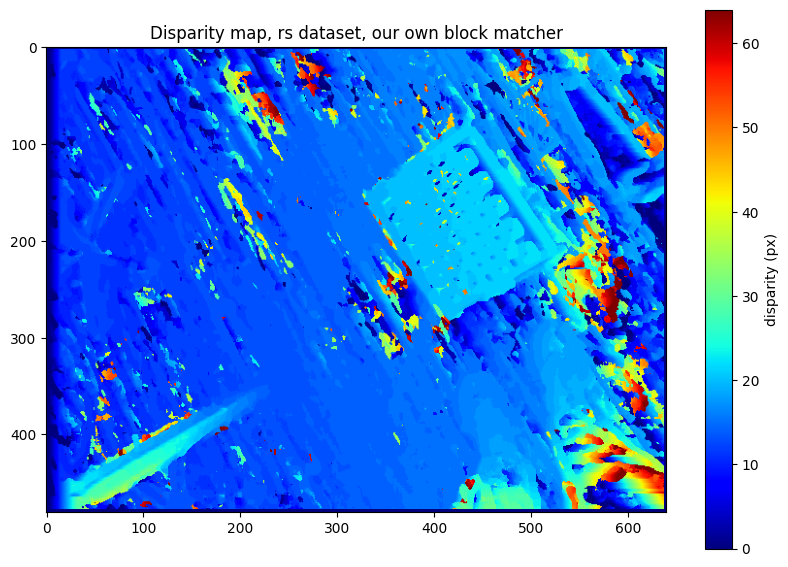

In [14]:
rect_l_gray = cv2.cvtColor(rect_l, cv2.COLOR_BGR2GRAY)
rect_r_gray = cv2.cvtColor(rect_r, cv2.COLOR_BGR2GRAY)

t0 = time.time()
disp = compute_disparity_map(rect_l_gray, rect_r_gray, block_size=7, max_disparity=64)
print(f'Computed in {time.time() - t0:.1f}s')

plt.figure(figsize=(10, 7))
plt.imshow(disp, cmap='jet')
plt.colorbar(label='disparity (px)')
plt.title('Disparity map, rs dataset, our own block matcher')
plt.show()


The checkerboard is closer to the camera than the floor, so it stands out with a different disparity. The floor shows a smooth gradient, since it is a flat surface receding away at an angle. There is some speckle noise, the wooden floor's repeating pattern occasionally confuses a simple SAD matcher with no post-processing.

## Repeating on the mynteye dataset

Same steps, same pattern size and square size, just a different folder. We reuse all the functions defined above.

In [15]:
objpoints2, imgpoints_l2, imgpoints_r2, image_size2 = find_stereo_corners('mynteye', PATTERN_SIZE, objp)
print(f'Valid pairs: {len(objpoints2)}, image size: {image_size2}')

ret_l2, mtx_l2, dist_l2, _, _ = cv2.calibrateCamera(objpoints2, imgpoints_l2, image_size2, None, None)
ret_r2, mtx_r2, dist_r2, _, _ = cv2.calibrateCamera(objpoints2, imgpoints_r2, image_size2, None, None)
print(f'Left camera reprojection error:  {ret_l2:.3f}')
print(f'Right camera reprojection error: {ret_r2:.3f}')

stereo_ret2, mtx_l2, dist_l2, mtx_r2, dist_r2, R2_, T2_, E2, F2 = cv2.stereoCalibrate(
    objpoints2, imgpoints_l2, imgpoints_r2,
    mtx_l2, dist_l2, mtx_r2, dist_r2, image_size2,
    flags=cv2.CALIB_FIX_INTRINSIC,
)
print(f'Stereo reprojection error: {stereo_ret2:.3f}')
print(f'Baseline: {np.linalg.norm(T2_):.1f} mm')


Valid pairs: 50, image size: (1280, 720)
Left camera reprojection error:  0.837
Right camera reprojection error: 0.749
Stereo reprojection error: 0.822
Baseline: 119.8 mm


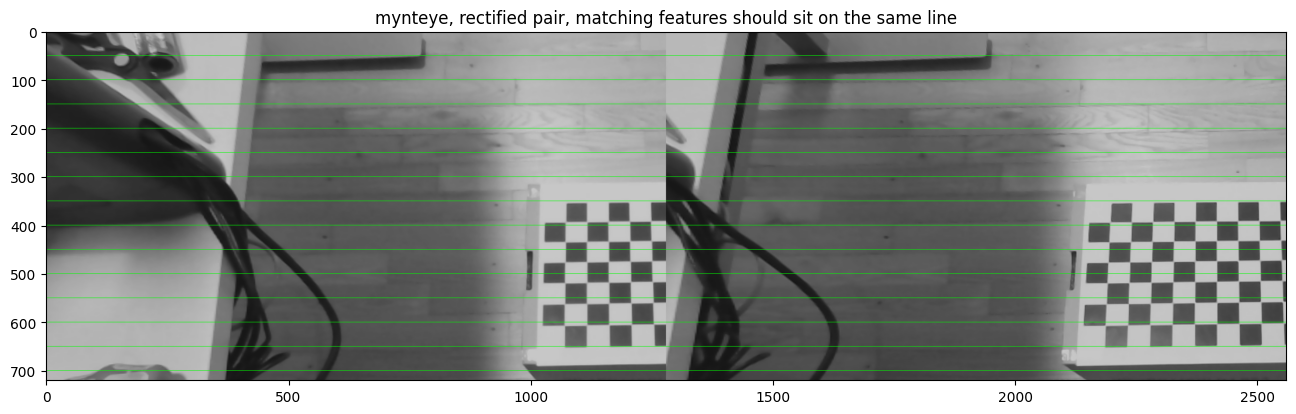

In [16]:
R1_2, R2_2, P1_2, P2_2, Q2, roi1_2, roi2_2 = cv2.stereoRectify(
    mtx_l2, dist_l2, mtx_r2, dist_r2, image_size2, R2_, T2_, alpha=0
)

map_l2, map_r2 = build_rectify_maps(mtx_l2, dist_l2, mtx_r2, dist_r2, R1_2, R2_2, P1_2, P2_2, image_size2)

img_l2 = cv2.imread('mynteye/left-0000.png')
img_r2 = cv2.imread('mynteye/right-0000.png')
rect_l2, rect_r2 = rectify_pair(img_l2, img_r2, map_l2, map_r2)

check_img2 = draw_rectification_check(rect_l2, rect_r2, step=50)
plt.figure(figsize=(16, 6))
plt.imshow(cv2.cvtColor(check_img2, cv2.COLOR_BGR2RGB))
plt.title('mynteye, rectified pair, matching features should sit on the same line')
plt.show()


Computed in 30.4s


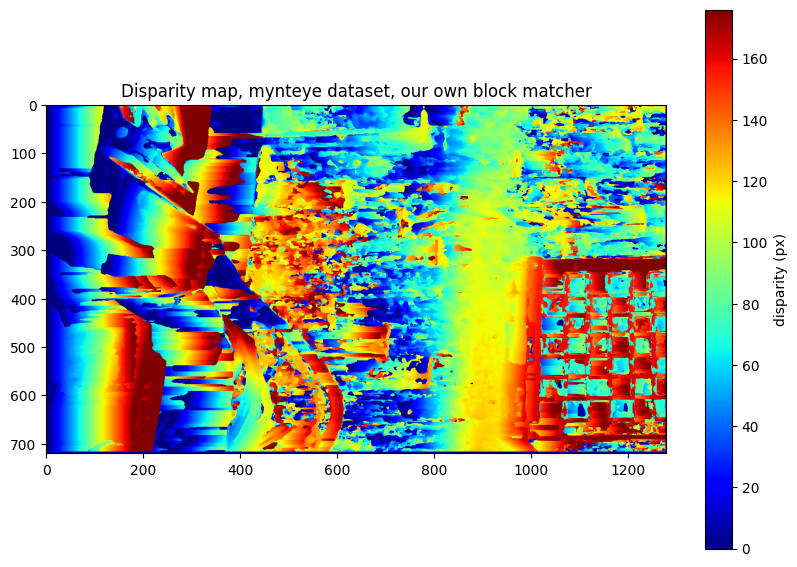

In [17]:
rect_l2_gray = cv2.cvtColor(rect_l2, cv2.COLOR_BGR2GRAY)
rect_r2_gray = cv2.cvtColor(rect_r2, cv2.COLOR_BGR2GRAY)

# mynteye has a bigger baseline and higher resolution than rs, so objects
# can shift further between the two views. We use a larger max_disparity
# to capture that, at the cost of a longer runtime.
t0 = time.time()
disp2 = compute_disparity_map(rect_l2_gray, rect_r2_gray, block_size=7, max_disparity=176)
print(f'Computed in {time.time() - t0:.1f}s')

plt.figure(figsize=(10, 7))
plt.imshow(disp2, cmap='jet')
plt.colorbar(label='disparity (px)')
plt.title('Disparity map, mynteye dataset, our own block matcher')
plt.show()


Both datasets go through the same pipeline: find corners in matching pairs, calibrate each camera, stereo calibrate, stereo rectify, undistort and remap the images, then run our own block matcher on the aligned pair.

Note: We used generative AI (ChatGPT) to proofread code and comments.